# Survey Comparison Analysis - PEER vs EXP

This notebook compares only two selected cross-group pairs:

1. `PEERknow` vs `EXPlearnint`
2. `PEERdislike` vs `EXPreceive`

The focus is on **juxtaposed group summaries** in tables and simple plots.


## 1) Imports and shared notebook helpers


In [132]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import fisher_exact, kruskal, mannwhitneyu

repo_root = Path.cwd().resolve()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from notebooks.survey_notebook_utils import (
    clean_text,
    load_group_context,
    one_index_from_col,
    subquestion_label_map,
    setup_notebook_style,
)

setup_notebook_style()


## 2) Load PEER, INT, and EXP contexts


In [133]:
peer_ctx = load_group_context('PEER')
int_ctx = load_group_context('INT')
exp_ctx = load_group_context('EXP')

peer_df = peer_ctx['group_df']
int_df = int_ctx['group_df']
exp_df = exp_ctx['group_df']

print(f"PEER respondents: {len(peer_df)}")
print(f"INT respondents:  {len(int_df)}")
print(f"EXP respondents:  {len(exp_df)}")


PEER respondents: 36
INT respondents:  37
EXP respondents:  15


## 3) Small helper functions for cross-group summaries


In [134]:
def dual_scale_summary(df: pd.DataFrame, subq: pd.DataFrame, question_code: str, scale_names: tuple[str, str]) -> pd.DataFrame:
    label_map = subquestion_label_map(subq, question_code)
    cols = sorted([c for c in df.columns if c.startswith(question_code + '[')])

    rows = []
    for c in cols:
        idx_text = c.replace(question_code, '').strip('[]')
        topic_idx, scale_idx = [int(x) for x in idx_text.split('][')]

        vals = pd.to_numeric(df[c], errors='coerce')
        rows.append({
            'topic_idx': topic_idx,
            'topic': label_map.get(topic_idx, f'Topic {topic_idx}'),
            'scale_idx': scale_idx,
            'scale': scale_names[scale_idx - 1],
            'n_answered': int(vals.notna().sum()),
            'mean': round(float(vals.mean()), 2) if vals.notna().any() else pd.NA,
        })

    out = pd.DataFrame(rows).sort_values(['topic_idx', 'scale_idx']).reset_index(drop=True)
    return out


def multi_select_pct_summary(df: pd.DataFrame, subq: pd.DataFrame, question_code: str) -> pd.DataFrame:
    label_map = subquestion_label_map(subq, question_code)
    cols = sorted(
        [c for c in df.columns if c.startswith(question_code + '[') and c != f'{question_code}[other]'],
        key=lambda x: one_index_from_col(x) or 999,
    )

    rows = []
    for c in cols:
        idx = one_index_from_col(c)
        label = label_map[idx] if idx is not None and idx in label_map else c
        raw = clean_text(df[c])
        selected = raw.str.lower().isin(['yes', '1', 'true', 'ja', 'y'])
        n_sel = int(selected.sum())
        rows.append({
            'item_idx': idx,
            'item': label,
            'n_selected': n_sel,
            'pct_selected': round(n_sel / len(df) * 100, 1),
        })

    out = pd.DataFrame(rows).sort_values('pct_selected', ascending=False).reset_index(drop=True)
    return out


def plot_shared_split_barh(
    data: pd.DataFrame,
    label_col: str,
    peer_value_col: str,
    exp_value_col: str,
    title: str,
    peer_label: str = 'PEER',
    exp_label: str = 'EXP',
    value_note: str = 'raw values shown in table above',
) -> None:
    plot_df = data[[label_col, peer_value_col, exp_value_col]].copy()
    plot_df = plot_df.dropna(subset=[peer_value_col, exp_value_col]).reset_index(drop=True)

    totals = plot_df[peer_value_col] + plot_df[exp_value_col]
    plot_df['peer_share'] = (plot_df[peer_value_col] / totals * 100).where(totals > 0, 0)
    plot_df['exp_share'] = (plot_df[exp_value_col] / totals * 100).where(totals > 0, 0)

    fig_h = max(4, 0.55 * len(plot_df))
    plt.figure(figsize=(11.5, fig_h))

    y = range(len(plot_df))
    plt.barh(y, plot_df['peer_share'], color='#1f77b4', label=peer_label)
    plt.barh(y, plot_df['exp_share'], left=plot_df['peer_share'], color='#ff7f0e', label=exp_label)

    min_label_width = 7.0
    for i, row in plot_df.iterrows():
        if row['peer_share'] >= min_label_width:
            plt.text(
                row['peer_share'] / 2,
                i,
                f"{row['peer_share']:.1f}%",
                ha='center',
                va='center',
                color='white',
                fontsize=9,
                fontweight='bold',
            )
        if row['exp_share'] >= min_label_width:
            plt.text(
                row['peer_share'] + row['exp_share'] / 2,
                i,
                f"{row['exp_share']:.1f}%",
                ha='center',
                va='center',
                color='white',
                fontsize=9,
                fontweight='bold',
            )

    plt.yticks(list(y), plot_df[label_col])
    plt.xlim(0, 100)
    plt.xlabel('Share of combined value per row (%)')
    plt.ylabel('Mapped theme')
    plt.title(title + f" ({value_note})")
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


## 4) Comparison A: `PEERknow` vs `EXPlearnint`

Both are dual-scale matrix questions, but scale meanings are not identical.

For a compact shared-bar view, I compare the most directly related scales:

- `PEER Interest` vs `EXP Interesting to teens`

(One horizontal bar per mapped theme, split into PEER vs EXP shares.)


In [135]:
peer_know = dual_scale_summary(
    peer_df,
    peer_ctx['subq'],
    question_code='PEERknow',
    scale_names=('Comfort', 'Interest'),
)

exp_learnint = dual_scale_summary(
    exp_df,
    exp_ctx['subq'],
    question_code='EXPlearnint',
    scale_names=('Important to learn', 'Interesting to teens'),
)

print('PEERknow summary:')
display(peer_know)
print('EXPlearnint summary:')
display(exp_learnint)


PEERknow summary:


,topic_idx,topic,scale_idx,scale,n_answered,mean
0,1,To grow plants,1,Comfort,32,2.81
1,1,To grow plants,2,Interest,32,2.88
2,2,"What plants need to grow (sun, water, minerals)",1,Comfort,32,3.56
3,2,"What plants need to grow (sun, water, minerals)",2,Interest,32,3.06
4,3,How food comes to our plate,1,Comfort,34,3.24
5,3,How food comes to our plate,2,Interest,35,3.57
6,4,Where which fruits and veggies come from,1,Comfort,34,3.18
7,4,Where which fruits and veggies come from,2,Interest,34,3.44
8,5,"Climate change (climate injustice, agriculture as driver for climate change)",1,Comfort,34,3.41
9,5,"Climate change (climate injustice, agriculture as driver for climate change)",2,Interest,34,3.74


EXPlearnint summary:


,topic_idx,topic,scale_idx,scale,n_answered,mean
0,1,Where food comes from (farm to plate),1,Important to learn,15,4.67
1,1,Where food comes from (farm to plate),2,Interesting to teens,12,3.67
2,2,Soil and what makes it “healthy”,1,Important to learn,14,3.71
3,2,Soil and what makes it “healthy”,2,Interesting to teens,12,3.00
4,3,Water use and saving water in farming,1,Important to learn,13,4.46
5,3,Water use and saving water in farming,2,Interesting to teens,12,3.17
6,4,Climate change & agriculture,1,Important to learn,14,4.71
7,4,Climate change & agriculture,2,Interesting to teens,12,4.17
8,5,Sustainability in agriculture,1,Important to learn,13,4.54
9,5,Sustainability in agriculture,2,Interesting to teens,12,3.83


In [136]:
mapped_topics = [
    {'peer_idx': 2, 'exp_idx': 2, 'theme': 'Soil'},
    {'peer_idx': 3, 'exp_idx': 1, 'theme': 'Farm-to-plate / food origin'},
    {'peer_idx': 5, 'exp_idx': 4, 'theme': 'Climate change'},
    {'peer_idx': 6, 'exp_idx': 8, 'theme': 'Biodiversity'},
    {'peer_idx': 7, 'exp_idx': 5, 'theme': 'Sustainability'},
    {'peer_idx': 10, 'exp_idx': 10, 'theme': 'Fertilizer / plant nutrition'},
    {'peer_idx': 12, 'exp_idx': 12, 'theme': 'Technology in farming'},
    {'peer_idx': 13, 'exp_idx': 11, 'theme': 'Food processing / preservation'},
    {'peer_idx': 1, 'exp_idx': 14, 'theme': 'Growing plants (basic/at home)'},
]

map_df = pd.DataFrame(mapped_topics)

peer_wide = (
    peer_know
    .pivot(index='topic_idx', columns='scale', values='mean')
    .rename(columns={'Comfort': 'peer_comfort_mean', 'Interest': 'peer_interest_mean'})
)
peer_names = peer_know[['topic_idx', 'topic']].drop_duplicates().rename(columns={'topic': 'peer_topic'})

exp_wide = (
    exp_learnint
    .pivot(index='topic_idx', columns='scale', values='mean')
    .rename(columns={
        'Important to learn': 'exp_important_mean',
        'Interesting to teens': 'exp_interesting_mean',
    })
)
exp_names = exp_learnint[['topic_idx', 'topic']].drop_duplicates().rename(columns={'topic': 'exp_topic'})

juxtaposed = (
    map_df
    .merge(peer_names, left_on='peer_idx', right_on='topic_idx', how='left')
    .drop(columns=['topic_idx'])
    .merge(peer_wide, left_on='peer_idx', right_index=True, how='left')
    .merge(exp_names, left_on='exp_idx', right_on='topic_idx', how='left')
    .drop(columns=['topic_idx'])
    .merge(exp_wide, left_on='exp_idx', right_index=True, how='left')
)

display(juxtaposed)


,peer_idx,exp_idx,theme,peer_topic,peer_comfort_mean,peer_interest_mean,exp_topic,exp_important_mean,exp_interesting_mean
0,2,2,Soil,"What plants need to grow (sun, water, minerals)",3.56,3.06,Soil and what makes it “healthy”,3.71,3.00
1,3,1,Farm-to-plate / food origin,How food comes to our plate,3.24,3.57,Where food comes from (farm to plate),4.67,3.67
2,5,4,Climate change,"Climate change (climate injustice, agriculture as driver for climate change)",3.41,3.74,Climate change & agriculture,4.71,4.17
3,6,8,Biodiversity,"Biodiversity (species, ecology, interactions)",2.85,3.64,"Biodiversity, insects & pollinators",4.46,4.00
4,7,5,Sustainability,"Sustainability (three pillars, Sustainable Development Goals,...)",2.85,3.18,Sustainability in agriculture,4.54,3.83
5,10,10,Fertilizer / plant nutrition,"Fertilizer (composition, pros/cons)",1.94,2.53,"Plant nutrition (fertilizer, compost)",4.00,3.08
6,12,12,Technology in farming,"Technology in farming (agriculture 4.0, farmdroids,...)",1.91,2.76,"Technology in farming (sensors, drones, AI)",3.23,3.50
7,13,11,Food processing / preservation,"Food Processing (shelf life, preserves, cooking,...)",2.97,3.39,"Food waste, storage & preservation",4.71,3.50
8,1,14,Growing plants (basic/at home),To grow plants,2.81,2.88,Urban gardening & growing food at home,4.29,3.67


,theme,peer_interest_mean,exp_interesting_mean,peer_comfort_mean,exp_important_mean
0,Soil,3.06,3.00,3.56,3.71
1,Farm-to-plate / food origin,3.57,3.67,3.24,4.67
2,Climate change,3.74,4.17,3.41,4.71
3,Biodiversity,3.64,4.00,2.85,4.46
4,Sustainability,3.18,3.83,2.85,4.54
5,Fertilizer / plant nutrition,2.53,3.08,1.94,4.00
6,Technology in farming,2.76,3.50,1.91,3.23
7,Food processing / preservation,3.39,3.50,2.97,4.71
8,Growing plants (basic/at home),2.88,3.67,2.81,4.29


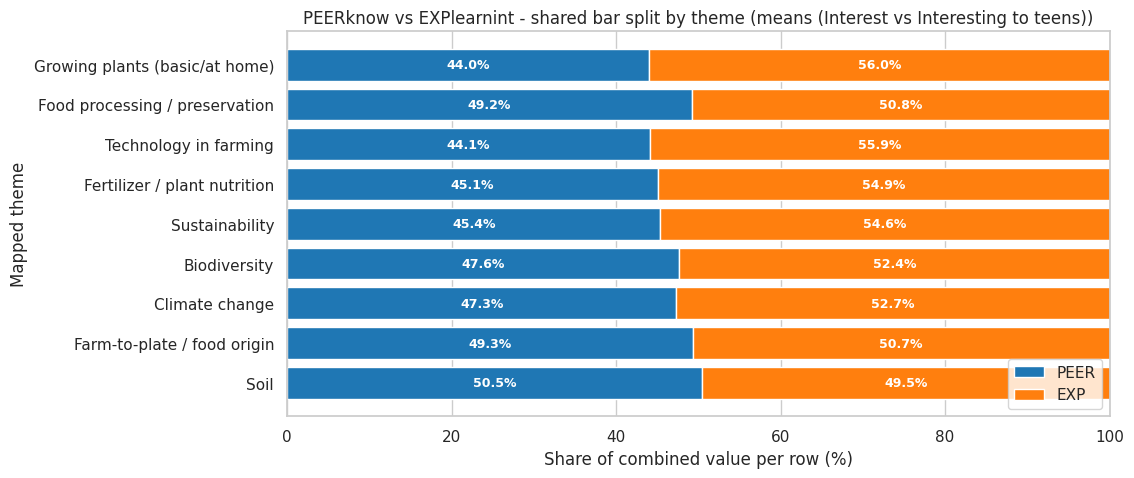

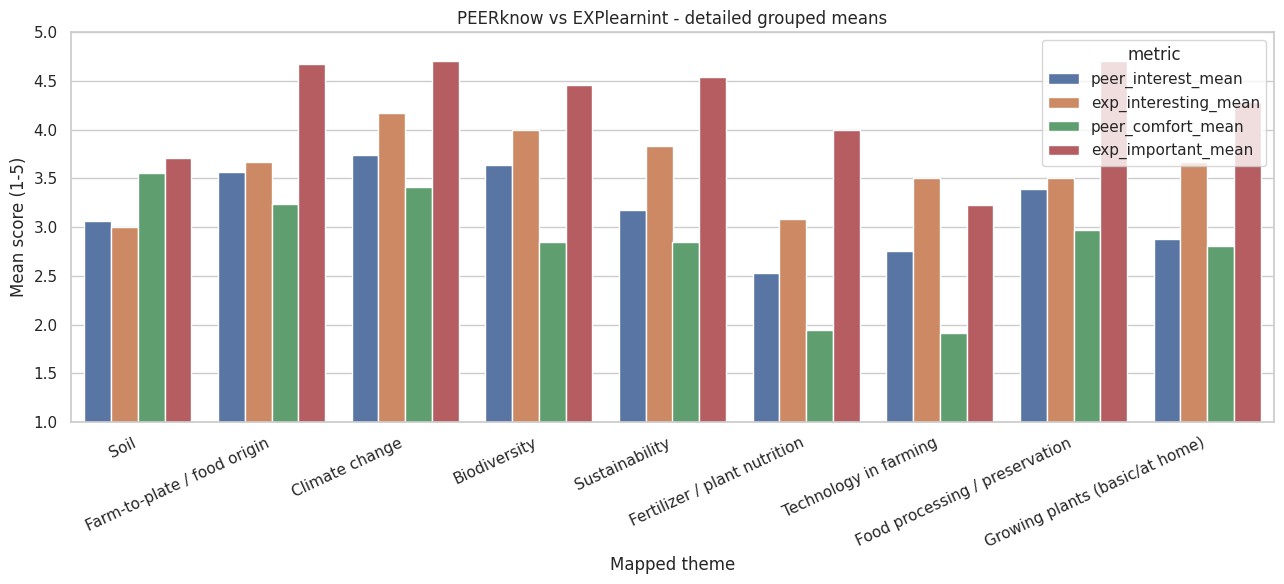

In [137]:
interest_compare = juxtaposed[[
    'theme',
    'peer_interest_mean',
    'exp_interesting_mean',
    'peer_comfort_mean',
    'exp_important_mean',
]].copy()

display(interest_compare)

plot_shared_split_barh(
    interest_compare,
    label_col='theme',
    peer_value_col='peer_interest_mean',
    exp_value_col='exp_interesting_mean',
    title='PEERknow vs EXPlearnint - shared bar split by theme',
    value_note='means (Interest vs Interesting to teens)',
)

plot_df = interest_compare.melt(
    id_vars=['theme'],
    value_vars=['peer_interest_mean', 'exp_interesting_mean', 'peer_comfort_mean', 'exp_important_mean'],
    var_name='metric',
    value_name='mean',
)
metric_order = ['peer_interest_mean', 'exp_interesting_mean', 'peer_comfort_mean', 'exp_important_mean']
plot_df['metric'] = pd.Categorical(plot_df['metric'], categories=metric_order, ordered=True)

plt.figure(figsize=(13, 6))
ax = sns.barplot(data=plot_df, x='theme', y='mean', hue='metric')
ax.set_ylim(1, 5)
ax.set_xlabel('Mapped theme')
ax.set_ylabel('Mean score (1-5)')
ax.set_title('PEERknow vs EXPlearnint - detailed grouped means')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


## 5) Comparison B: `PEERdislike` vs `EXPreceive`

Both are multi-select questions (`M`).

I compare selected percentages and add one explicit mapping table so PEER and EXP options can be viewed side-by-side.


In [138]:
peer_dislike = multi_select_pct_summary(peer_df, peer_ctx['subq'], 'PEERdislike')
exp_receive = multi_select_pct_summary(exp_df, exp_ctx['subq'], 'EXPreceive')

print('PEERdislike:')
display(peer_dislike)
print('EXPreceive:')
display(exp_receive)


PEERdislike:


,item_idx,item,n_selected,pct_selected
0,6,Too slow or boring,24,66.7
1,1,Too much reading,23,63.9
2,3,Not allowed to touch anything,14,38.9
3,7,Too similar to school,13,36.1
4,9,Not designed for people my age (rather for adults),10,27.8
5,4,Being indoors for a long time,9,25.0
6,5,I don't like the presented topics,7,19.4
7,2,Being told to be quiet,6,16.7
8,10,I generally don’t like museums,6,16.7
9,8,Being patronised,4,11.1


EXPreceive:


,item_idx,item,n_selected,pct_selected
0,1,Long text panels,13,86.7
1,6,Lack of relevance to everyday life,10,66.7
2,5,Overly complex scientific language,10,66.7
3,3,"Strict behavioral rules (e.g. silence, no movement)",7,46.7
4,2,"Passive formats (listening, reading)",5,33.3
5,4,Lack of social interaction,4,26.7
6,7,Intention of teaching something (vs. unintended exploration),1,6.7


In [139]:
mapped_dislike_receive = [
    {'peer_idx': 1, 'exp_idx': 1, 'theme': 'Too much text/reading'},
    {'peer_idx': 2, 'exp_idx': 3, 'theme': 'Strict behavior rules'},
    {'peer_idx': 3, 'exp_idx': 3, 'theme': 'No touching / rigid rules'},
    {'peer_idx': 6, 'exp_idx': 2, 'theme': 'Passive / boring format'},
    {'peer_idx': 7, 'exp_idx': 7, 'theme': 'Feels like school/teaching intent'},
    {'peer_idx': 8, 'exp_idx': 5, 'theme': 'Patronizing / too academic'},
    {'peer_idx': 9, 'exp_idx': 6, 'theme': 'Not relevant for teens'},
    {'peer_idx': 11, 'exp_idx': 3, 'theme': 'Unclear behavior expectations'},
]

map_m = pd.DataFrame(mapped_dislike_receive)

peer_m = peer_dislike[['item_idx', 'item', 'pct_selected']].rename(
    columns={'item_idx': 'peer_idx', 'item': 'peer_item', 'pct_selected': 'peer_pct_selected'}
)
exp_m = exp_receive[['item_idx', 'item', 'pct_selected']].rename(
    columns={'item_idx': 'exp_idx', 'item': 'exp_item', 'pct_selected': 'exp_pct_selected'}
)

juxtaposed_m = map_m.merge(peer_m, on='peer_idx', how='left').merge(exp_m, on='exp_idx', how='left')
display(juxtaposed_m)


,peer_idx,exp_idx,theme,peer_item,peer_pct_selected,exp_item,exp_pct_selected
0,1,1,Too much text/reading,Too much reading,63.9,Long text panels,86.7
1,2,3,Strict behavior rules,Being told to be quiet,16.7,"Strict behavioral rules (e.g. silence, no movement)",46.7
2,3,3,No touching / rigid rules,Not allowed to touch anything,38.9,"Strict behavioral rules (e.g. silence, no movement)",46.7
3,6,2,Passive / boring format,Too slow or boring,66.7,"Passive formats (listening, reading)",33.3
4,7,7,Feels like school/teaching intent,Too similar to school,36.1,Intention of teaching something (vs. unintended exploration),6.7
5,8,5,Patronizing / too academic,Being patronised,11.1,Overly complex scientific language,66.7
6,9,6,Not relevant for teens,Not designed for people my age (rather for adults),27.8,Lack of relevance to everyday life,66.7
7,11,3,Unclear behavior expectations,Not knowing how to behave in these spaces,8.3,"Strict behavioral rules (e.g. silence, no movement)",46.7


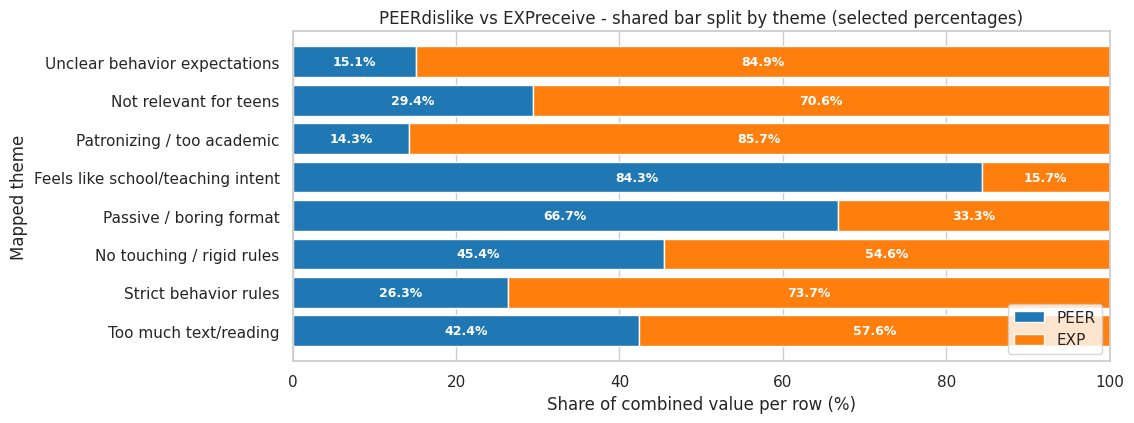

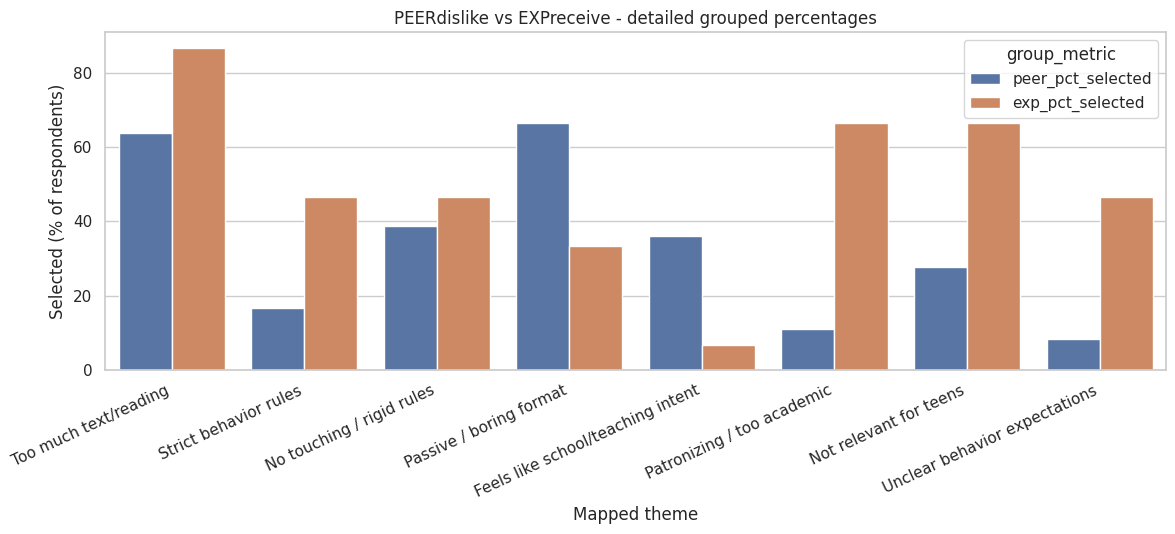

In [140]:
plot_shared_split_barh(
    juxtaposed_m,
    label_col='theme',
    peer_value_col='peer_pct_selected',
    exp_value_col='exp_pct_selected',
    title='PEERdislike vs EXPreceive - shared bar split by theme',
    value_note='selected percentages',
)

plot_m = juxtaposed_m.melt(
    id_vars=['theme'],
    value_vars=['peer_pct_selected', 'exp_pct_selected'],
    var_name='group_metric',
    value_name='pct_selected',
)

plt.figure(figsize=(12, 5.5))
ax = sns.barplot(data=plot_m, x='theme', y='pct_selected', hue='group_metric')
ax.set_xlabel('Mapped theme')
ax.set_ylabel('Selected (% of respondents)')
ax.set_title('PEERdislike vs EXPreceive - detailed grouped percentages')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


## 6) Why These Tests (and not ANOVA)

I use simple tests that fit the current data structure and sample sizes (`PEER n=36`, `EXP n=15`):

- `Mann-Whitney U` for the knowledge/interest composite:
  - compares two independent groups,
  - does not require normality,
  - robust for ordinal-like 1-5 ratings and unequal/small group sizes.

- `Fisher's Exact Test` for exhibition items:
  - each mapped item is binary (`selected` vs `not selected`),
  - exact test is preferred over chi-square when counts can be small,
  - appropriate for small samples.

Why not ANOVA here:

- ANOVA targets mean differences under stronger assumptions (approx. normal residuals, homoscedasticity, interval-scale interpretation).
- Our core item-level comparisons are mostly ordinal (Likert) and binary multi-select outcomes.
- For two-group comparisons in this setting, Mann-Whitney/Fisher are more defensible and easier to communicate.

Note:

- These tests are exploratory in this notebook.
- I therefore report raw percentages/means and effect-size-oriented summaries alongside p-values.


### Interdisciplinary Framing (Social-Science and Natural-Science Logic)

This comparison follows an **interdisciplinary empirical approach**.

- From a **social-science perspective**, the instrument captures attitudes, perceptions, and preferences (Likert-style ratings and multi-select responses). The analysis therefore emphasizes group comparison for ordinal/binary survey outcomes.

- From a **natural-science perspective** (horticultural sciences), the workflow remains hypothesis-oriented, transparent, and reproducible: clearly defined groups (`PEER`, `EXP`), explicit variable mapping, quantitative effect summaries, exact/non-parametric inference, and multiple-testing control.

In this sense, the study is not “less scientific” because it uses survey data. It applies scientific reasoning to human-centered evidence relevant for horticultural knowledge transfer and exhibition design.


## 7) Statistical Quick-Check and Interpretation

This section adds simple inferential checks suited for small sample sizes:

- `Mann-Whitney U` (non-parametric) for respondent-level scores in the knowledge/interest comparison.
- `Fisher's Exact Test` per mapped exhibition theme (binary selected/not selected).

Results are exploratory and complement (not replace) the descriptive plots.


### Test Recap (Plain Language)

I use a small set of tests that fit survey data and small groups:

- `Kruskal-Wallis`:
  - Use when comparing **3 independent groups** (here: PEER vs INT vs EXP).
  - Real-world intuition: asks whether one group tends to give generally higher/lower ratings than the others.

- `Mann-Whitney U`:
  - Use for **2-group follow-up comparisons**.
  - Real-world intuition: compares rank positions of answers, not strict normal-distribution means.

- `Fisher's Exact Test`:
  - Use for **binary selected/not-selected** comparisons in small samples.
  - Real-world intuition: checks whether differences in option uptake could plausibly occur by chance.

- `FDR (Benjamini-Hochberg)` correction:
  - Applied when I run many related tests.
  - Real-world intuition: reduces false-positive risk from multiple comparisons.


### Main 3-Group Plots (PEER vs INT vs EXP)

These plots visualize the same mapped interest composite used in the Kruskal-Wallis test.


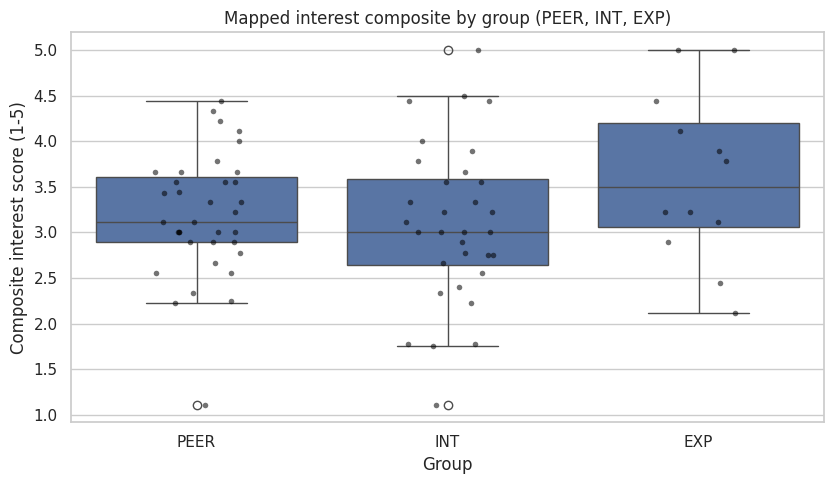

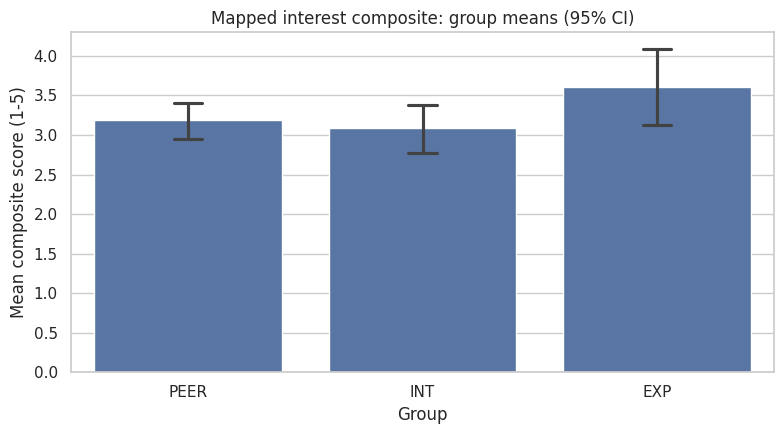

In [141]:
peer_interest_cols = [f"PEERknow[{idx}][2]" for idx in map_df['peer_idx']]
int_interest_cols = [f"INTknow[{idx}][2]" for idx in map_df['exp_idx']]
exp_interest_cols = [f"EXPlearnint[{idx}][2]" for idx in map_df['exp_idx']]

peer_interest_score = peer_df[peer_interest_cols].apply(pd.to_numeric, errors='coerce').mean(axis=1, skipna=True).dropna()
int_interest_score = int_df[int_interest_cols].apply(pd.to_numeric, errors='coerce').mean(axis=1, skipna=True).dropna()
exp_interest_score = exp_df[exp_interest_cols].apply(pd.to_numeric, errors='coerce').mean(axis=1, skipna=True).dropna()

plot_three = pd.DataFrame({
    'score': pd.concat([peer_interest_score, int_interest_score, exp_interest_score], ignore_index=True),
    'group': (['PEER'] * len(peer_interest_score)) + (['INT'] * len(int_interest_score)) + (['EXP'] * len(exp_interest_score)),
})

plt.figure(figsize=(8.5, 5))
ax = sns.boxplot(data=plot_three, x='group', y='score', whis=1.5)
sns.stripplot(data=plot_three, x='group', y='score', color='black', alpha=0.55, size=4, jitter=0.18)
ax.set_title('Mapped interest composite by group (PEER, INT, EXP)')
ax.set_xlabel('Group')
ax.set_ylabel('Composite interest score (1-5)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(data=plot_three, x='group', y='score', estimator='mean', errorbar=('ci', 95), capsize=0.12)
ax.set_title('Mapped interest composite: group means (95% CI)')
ax.set_xlabel('Group')
ax.set_ylabel('Mean composite score (1-5)')
plt.tight_layout()
plt.show()


### Coarse 3-Group Finding (Main Comparable Question)

Using the mapped interest composite (the only directly comparable structure across all three groups), the descriptive pattern is:

- `INT` rates expected teen interest slightly lower than `PEER` self-reported interest.
- `EXP` rates expected teen interest slightly higher than `PEER` self-reported interest.

Observed means in this dataset:

- `PEER`: 3.19 (`n=35`)
- `INT`: 3.09 (`n=32`)
- `EXP`: 3.60 (`n=12`)

Inference for this coarse endpoint:

- `Kruskal-Wallis`: `H=2.753`, `p=0.2524` (no statistically detectable global 3-group difference).
- Pairwise follow-ups are also non-significant after FDR correction.
- The 95% CI bars overlap in the group-mean plot, consistent with weak statistical separation.

Interpretation: the directional pattern (INT slightly under, EXP slightly over relative to PEER) is **descriptively plausible**, but with current sample sizes it should be treated as **suggestive, not conclusive**.


In [142]:
peer_interest_cols = [f"PEERknow[{idx}][2]" for idx in map_df['peer_idx']]
int_interest_cols = [f"INTknow[{idx}][2]" for idx in map_df['exp_idx']]
exp_interest_cols = [f"EXPlearnint[{idx}][2]" for idx in map_df['exp_idx']]

peer_interest_score = peer_df[peer_interest_cols].apply(pd.to_numeric, errors='coerce').mean(axis=1, skipna=True).dropna()
int_interest_score = int_df[int_interest_cols].apply(pd.to_numeric, errors='coerce').mean(axis=1, skipna=True).dropna()
exp_interest_score = exp_df[exp_interest_cols].apply(pd.to_numeric, errors='coerce').mean(axis=1, skipna=True).dropna()

kw_stat, kw_p = kruskal(peer_interest_score, int_interest_score, exp_interest_score)

main_three_group = pd.DataFrame([
    {'group': 'PEER', 'n': len(peer_interest_score), 'mean_interest_score': round(float(peer_interest_score.mean()), 3), 'median_interest_score': round(float(peer_interest_score.median()), 3)},
    {'group': 'INT', 'n': len(int_interest_score), 'mean_interest_score': round(float(int_interest_score.mean()), 3), 'median_interest_score': round(float(int_interest_score.median()), 3)},
    {'group': 'EXP', 'n': len(exp_interest_score), 'mean_interest_score': round(float(exp_interest_score.mean()), 3), 'median_interest_score': round(float(exp_interest_score.median()), 3)},
])

print('Mapped interest composite (3-group) summary:')
display(main_three_group)
print(f"Kruskal-Wallis H = {kw_stat:.3f}, p = {kw_p:.4f}")

pairs = [
    ('PEER', peer_interest_score, 'INT', int_interest_score),
    ('PEER', peer_interest_score, 'EXP', exp_interest_score),
    ('INT', int_interest_score, 'EXP', exp_interest_score),
]

pair_rows = []
for g1, s1, g2, s2 in pairs:
    u_stat, p_val = mannwhitneyu(s1, s2, alternative='two-sided')
    rb = (2 * u_stat) / (len(s1) * len(s2)) - 1
    pair_rows.append({
        'pair': f'{g1} vs {g2}',
        'n_1': len(s1),
        'n_2': len(s2),
        'U': float(u_stat),
        'p_value': float(p_val),
        'rank_biserial': float(rb),
    })

pairwise_df = pd.DataFrame(pair_rows).sort_values('p_value').reset_index(drop=True)

pvals = pairwise_df['p_value'].astype(float).values
m = len(pvals)
order = pvals.argsort()
ranked = pvals[order]
bh_vals = ranked * m / (pd.Series(range(1, m + 1)).values)
bh_vals = pd.Series(bh_vals[::-1]).cummin()[::-1].clip(upper=1.0).values
p_adj = pd.Series(index=order, data=bh_vals).sort_index().values
pairwise_df['p_fdr_bh'] = pd.Series(p_adj).round(4)
pairwise_df['p_value'] = pairwise_df['p_value'].round(4)
pairwise_df['U'] = pairwise_df['U'].round(2)
pairwise_df['rank_biserial'] = pairwise_df['rank_biserial'].round(3)

display(pairwise_df)

def is_selected(series: pd.Series) -> pd.Series:
    raw = clean_text(series)
    return raw.str.lower().isin(['yes', '1', 'true', 'ja', 'y'])

fisher_rows = []
for _, r in map_m.iterrows():
    peer_col = f"PEERdislike[{int(r['peer_idx'])}]"
    exp_col = f"EXPreceive[{int(r['exp_idx'])}]"

    peer_sel = is_selected(peer_df[peer_col])
    exp_sel = is_selected(exp_df[exp_col])

    peer_yes = int(peer_sel.sum())
    peer_no = int(len(peer_sel) - peer_yes)
    exp_yes = int(exp_sel.sum())
    exp_no = int(len(exp_sel) - exp_yes)

    odds_ratio, p_fisher = fisher_exact([[peer_yes, peer_no], [exp_yes, exp_no]], alternative='two-sided')

    fisher_rows.append({
        'theme': r['theme'],
        'peer_yes': peer_yes,
        'peer_n': int(len(peer_sel)),
        'peer_pct': round(peer_yes / len(peer_sel) * 100, 1),
        'exp_yes': exp_yes,
        'exp_n': int(len(exp_sel)),
        'exp_pct': round(exp_yes / len(exp_sel) * 100, 1),
        'odds_ratio': float(odds_ratio),
        'p_value': float(p_fisher),
    })

fisher_df = pd.DataFrame(fisher_rows).sort_values('p_value').reset_index(drop=True)
fisher_df['p_value'] = fisher_df['p_value'].round(4)
fisher_df['odds_ratio'] = fisher_df['odds_ratio'].round(3)
fisher_df['abs_diff_pp'] = (fisher_df['peer_pct'] - fisher_df['exp_pct']).abs().round(1)

pvals = fisher_df['p_value'].astype(float).values
m = len(pvals)
order = pvals.argsort()
ranked = pvals[order]
bh_vals = ranked * m / (pd.Series(range(1, m + 1)).values)
bh_vals = pd.Series(bh_vals[::-1]).cummin()[::-1].clip(upper=1.0).values
p_adj = pd.Series(index=order, data=bh_vals).sort_index().values
fisher_df['p_fdr_bh'] = pd.Series(p_adj).round(4)

print('Exhibition mapped-theme Fisher tests:')
display(fisher_df)



Mapped interest composite (3-group) summary:


,group,n,mean_interest_score,median_interest_score
0,PEER,35,3.191,3.111
1,INT,32,3.088,3.000
2,EXP,12,3.602,3.500


Kruskal-Wallis H = 2.753, p = 0.2524


,pair,n_1,n_2,U,p_value,rank_biserial,p_fdr_bh
0,INT vs EXP,32,12,133.0,0.1227,-0.307,0.2867
1,PEER vs EXP,35,12,156.0,0.1911,-0.257,0.2867
2,PEER vs INT,35,32,611.5,0.5212,0.092,0.5212


Exhibition mapped-theme Fisher tests:


,theme,peer_yes,peer_n,peer_pct,exp_yes,exp_n,exp_pct,odds_ratio,p_value,abs_diff_pp,p_fdr_bh
0,Patronizing / too academic,4,36,11.1,10,15,66.7,0.062,0.0001,55.6,0.0008
1,Unclear behavior expectations,3,36,8.3,7,15,46.7,0.104,0.0039,38.4,0.0156
2,Not relevant for teens,10,36,27.8,10,15,66.7,0.192,0.0134,38.9,0.0357
3,Passive / boring format,24,36,66.7,5,15,33.3,4.000,0.0356,33.4,0.0548
4,Strict behavior rules,6,36,16.7,7,15,46.7,0.229,0.0369,30.0,0.0548
5,Feels like school/teaching intent,13,36,36.1,1,15,6.7,7.913,0.0411,29.4,0.0548
6,Too much text/reading,23,36,63.9,13,15,86.7,0.272,0.1770,22.8,0.2023
7,No touching / rigid rules,14,36,38.9,7,15,46.7,0.727,0.7565,7.8,0.7565


### Statistical Result Summary

The tables and plots above show the numeric outputs.

- For the mapped 3-group interest endpoint (PEER/INT/EXP), the Kruskal-Wallis test is not significant.
- Pairwise Mann-Whitney follow-ups are not significant after FDR correction.
- For PEER vs EXP exhibition-reception themes, several differences are visible descriptively; after FDR, only a subset remains statistically robust.

Interpretive wording is kept in markdown blocks, while code cells focus on results.


## 8) Supplementary 2-Group Comparison: `INTfin` vs `EXPfinlimit`

This supplementary comparison keeps the same statistical logic as above.

Scale alignment used:
- `INTfin`: 1 = not constrained, 5 = strongly constrained
- `EXPfinlimit`: 1 = strongly constrained, 5 = not constrained

To compare both groups on the same meaning, I reverse EXP to:
- `EXP_aligned = 6 - EXPfinlimit`

After alignment, higher values always mean: **stronger perceived budget constraints**.


In [143]:
int_fin = pd.to_numeric(int_df['INTfin'], errors='coerce')
exp_fin_raw = pd.to_numeric(exp_df['EXPfinlimit'], errors='coerce')
exp_fin_aligned = 6 - exp_fin_raw

fin_summary = pd.DataFrame([
    {
        'group': 'INT',
        'n_answered': int(int_fin.notna().sum()),
        'mean_constraint_score': round(float(int_fin.mean()), 3),
        'median_constraint_score': round(float(int_fin.median()), 3),
    },
    {
        'group': 'EXP (aligned)',
        'n_answered': int(exp_fin_aligned.notna().sum()),
        'mean_constraint_score': round(float(exp_fin_aligned.mean()), 3),
        'median_constraint_score': round(float(exp_fin_aligned.median()), 3),
    },
])

display(fin_summary)


,group,n_answered,mean_constraint_score,median_constraint_score
0,INT,32,4.0,4.0
1,EXP (aligned),8,3.0,3.0


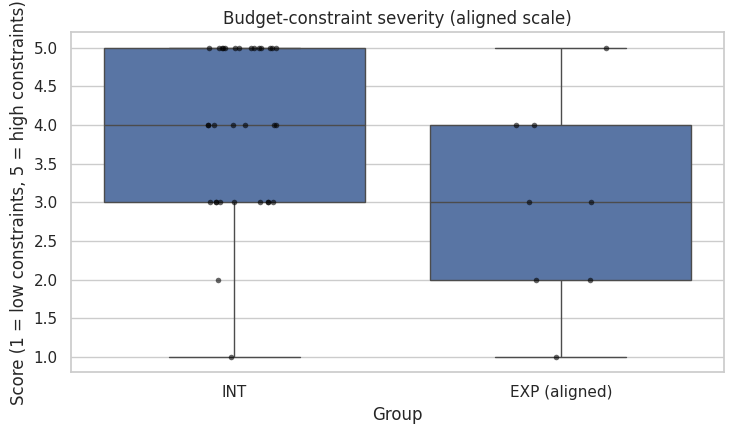

In [144]:
plot_fin = pd.DataFrame({
    'score': pd.concat([int_fin.dropna(), exp_fin_aligned.dropna()], ignore_index=True),
    'group': ['INT'] * int(int_fin.notna().sum()) + ['EXP (aligned)'] * int(exp_fin_aligned.notna().sum()),
})

plt.figure(figsize=(7.5, 4.5))
ax = sns.boxplot(data=plot_fin, x='group', y='score', whis=1.5)
sns.stripplot(data=plot_fin, x='group', y='score', color='black', alpha=0.6, size=4, jitter=0.14)
ax.set_title('Budget-constraint severity (aligned scale)')
ax.set_xlabel('Group')
ax.set_ylabel('Score (1 = low constraints, 5 = high constraints)')
plt.tight_layout()
plt.show()


In [145]:
u_fin, p_fin = mannwhitneyu(int_fin.dropna(), exp_fin_aligned.dropna(), alternative='two-sided')
rb_fin = (2 * u_fin) / (int(int_fin.notna().sum()) * int(exp_fin_aligned.notna().sum())) - 1

fin_test = pd.DataFrame([
    {
        'INT_n': int(int_fin.notna().sum()),
        'EXP_n_aligned': int(exp_fin_aligned.notna().sum()),
        'MannWhitney_U': round(float(u_fin), 2),
        'p_value': round(float(p_fin), 4),
        'rank_biserial': round(float(rb_fin), 3),
    }
])

display(fin_test)


,INT_n,EXP_n_aligned,MannWhitney_U,p_value,rank_biserial
0,32,8,185.5,0.0439,0.449


### Interpretation (Supplementary)

- This test asks whether `INT` and `EXP` differ in their overall rating of budget-constraint severity.
- With the current small EXP sample, this result should be treated as supplementary evidence.
- Report this together with the descriptive summary and plot above.


## 9) Notes

- Each comparison now shows both views: condensed shared split bars and detailed grouped bars.
- Shared split bars show relative PEER-vs-EXP composition per mapped row.
- Detailed grouped bars preserve absolute means/percentages.
- Mapping tables stay explicit and editable because wording is not fully identical across groups.
